In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for our plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

In [6]:

file_path = '../data_store/Sleep_health_and_lifestyle_dataset.csv'
df = pd.read_csv(file_path)

print(f"Dataset Shape: {df.shape}")
display(df.head())
print("\n--- Data Info ---")
display(df.info())

Dataset Shape: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea



--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB


None

In [7]:
# 1. Fill NaNs in the target variable with 'None' (Healthy)
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# 2. Split Blood Pressure string into two numeric columns
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df = df.drop('Blood Pressure', axis=1) # Drop the original string column

# 3. Clean up 'BMI Category' 
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

# 4. Drop 'Person ID' because it has no mathematical relationship to health
df = df.drop('Person ID', axis=1)

print("✅ Initial Cleaning Done. Ready for EDA. Here is the updated dataframe:")
display(df.head(3))

✅ Initial Cleaning Done. Ready for EDA. Here is the updated dataframe:


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80


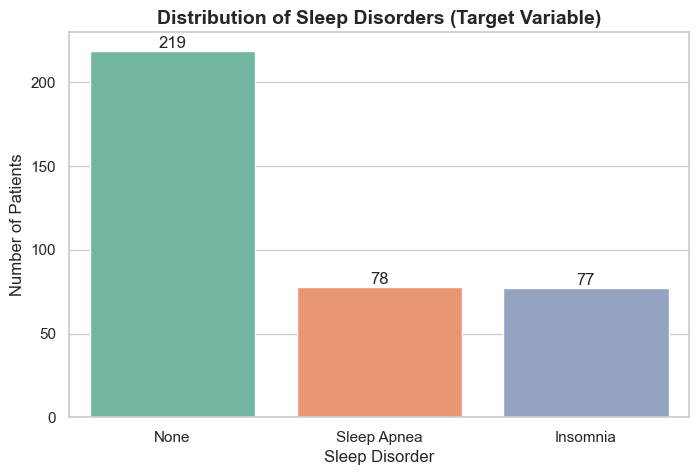

In [8]:
#This plot will tell us if we have a class imbalance problem (e.g., way more healthy people than depressed/insomnia patients).
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Sleep Disorder', order=['None', 'Sleep Apnea', 'Insomnia'], palette='Set2')
plt.title('Distribution of Sleep Disorders (Target Variable)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Patients')

# Add exact count numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.show()

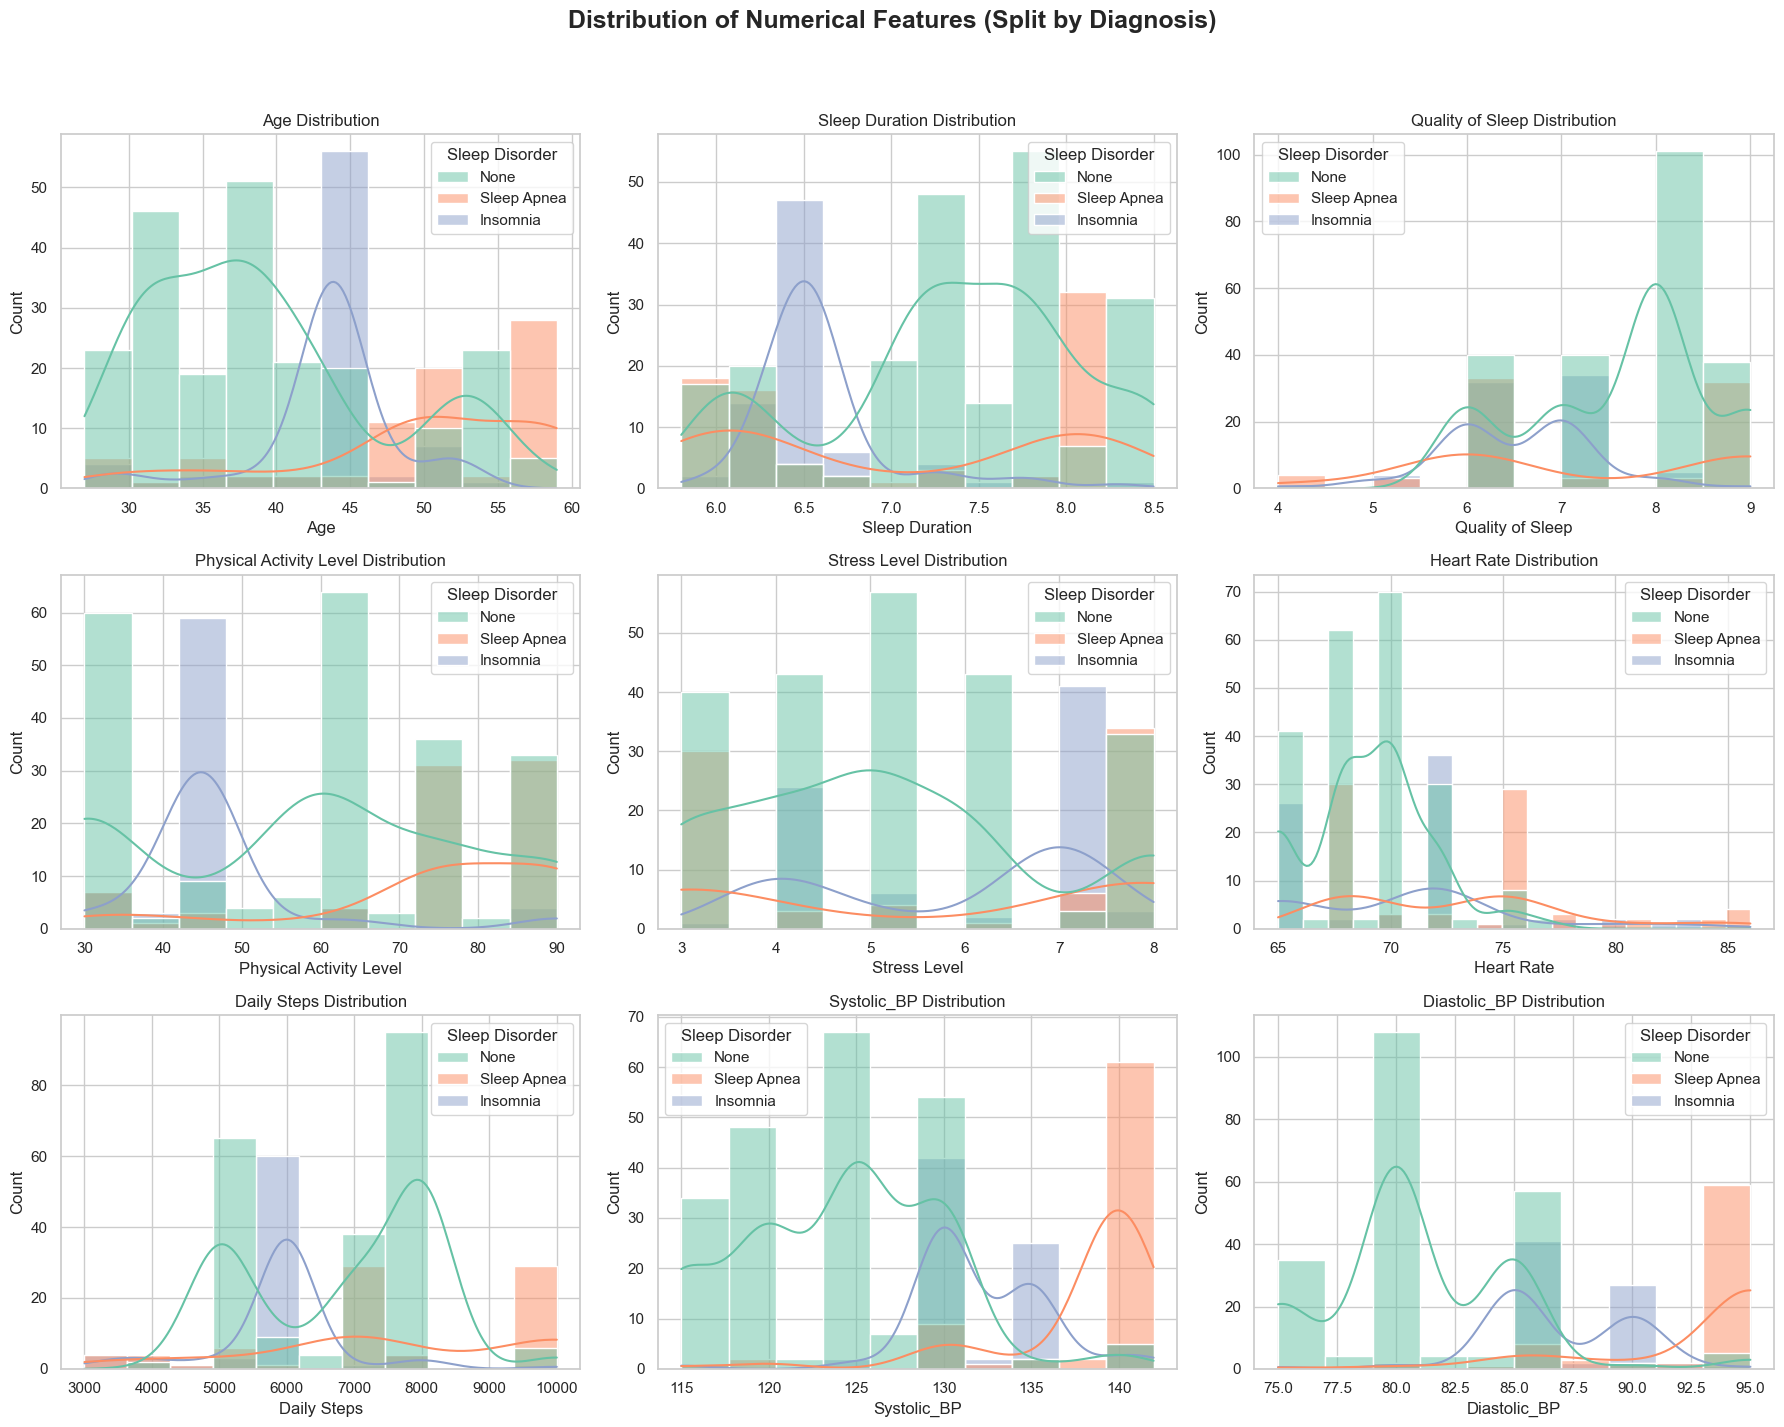

In [9]:
#This massive grid will plot histograms of every numerical feature (Age, Heart Rate, Steps, etc.) and color-code them based on whether the person has a sleep disorder. Watch how Heart Rate and Stress Level shift for diseased patients!
num_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 
            'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Distribution of Numerical Features (Split by Diagnosis)', fontsize=18, fontweight='bold')

for i, col in enumerate(num_cols):
    row, col_idx = i // 3, i % 3
    sns.histplot(data=df, x=col, kde=True, ax=axes[row, col_idx], hue='Sleep Disorder', palette='Set2')
    axes[row, col_idx].set_title(f'{col} Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

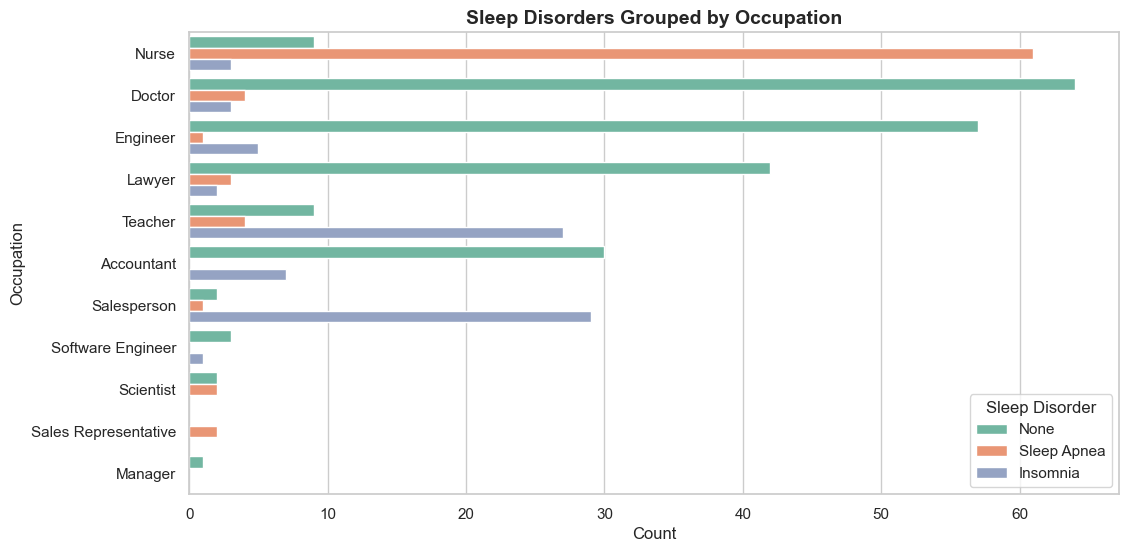

In [10]:
#Maps to highly stressful jobs
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Occupation', hue='Sleep Disorder', palette='Set2', 
              order=df['Occupation'].value_counts().index)
plt.title('Sleep Disorders Grouped by Occupation', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Occupation')
plt.show()

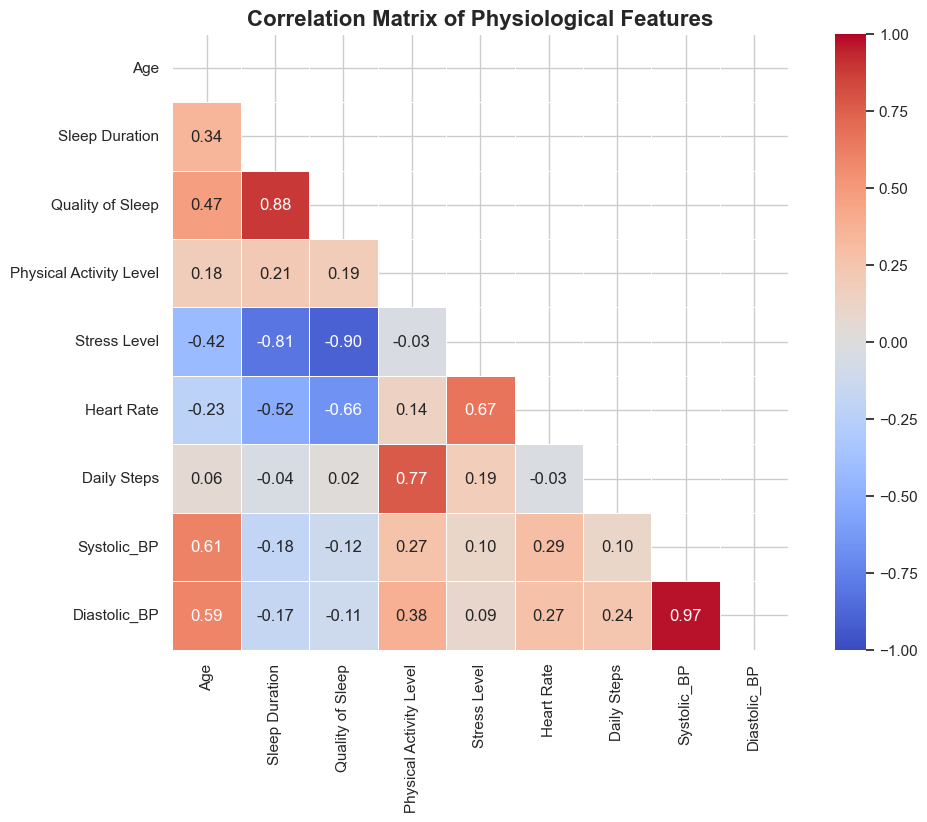

In [11]:
plt.figure(figsize=(12, 8))
# Calculate correlations only for numeric columns
corr_matrix = df[num_cols].corr()

# Create a mask to hide the upper triangle (makes it cleaner to read)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, square=True, linewidths=.5)
plt.title('Correlation Matrix of Physiological Features', fontsize=16, fontweight='bold')
plt.show()

In [12]:
#we convert the raw text into clinically relevant proxies. Notice how we map Occupation into a dense Occupational_Stress_Index to handle high-stress profiles like Astronauts.
from sklearn.preprocessing import LabelEncoder

def engineer_features(input_df):
    df_feat = input_df.copy()
    
    # 1. Occupational Stress Mapping (The Astronaut Proxy)
    # Map terrestrial jobs to clinical stress/circadian disruption profiles
    stress_map = {
        'Manager': 4, 'Accountant': 2, 'Scientist': 5, 'Lawyer': 6,
        'Software Engineer': 5, 'Teacher': 6, 'Doctor': 8,
        'Salesperson': 7, 'Nurse': 9, 'Sales Representative': 9
    }
    df_feat['Occupational_Stress_Index'] = df_feat['Occupation'].map(stress_map).fillna(5)
    
    # 2. Ordinal Encoding for BMI Category
    bmi_map = {'Normal': 0, 'Overweight': 1, 'Obese': 2}
    df_feat['BMI_Score'] = df_feat['BMI Category'].map(bmi_map).fillna(0)
    
    # 3. Binary Encoding for Gender
    df_feat['Is_Male'] = df_feat['Gender'].map({'Male': 1, 'Female': 0})
    
    # 4. Advanced Clinical Proxy Features
    # Restorative Rest Proxy: Interaction between length and perceived quality
    df_feat['Restorative_Rest_Score'] = df_feat['Sleep Duration'] * df_feat['Quality of Sleep']
    
    # Nocturnal Strain Proxy: Elevated heart rate paired with poor sleep duration
    df_feat['Nocturnal_Strain_Index'] = df_feat['Heart Rate'] / (df_feat['Sleep Duration'] + 1e-5)
    
    # Cardiovascular Load Proxy: Systolic tension relative to heart rate
    df_feat['Cardio_Load_Factor'] = df_feat['Systolic_BP'] / (df_feat['Heart Rate'] + 1e-5)
    
    # Activity Intensity: Steps taken relative to reported activity level
    df_feat['Step_Intensity'] = df_feat['Daily Steps'] / (df_feat['Physical Activity Level'] + 1e-5)
    
    # 5. Drop raw columns that have been fully transformed
    cols_to_drop = ['Gender', 'Occupation', 'BMI Category']
    df_feat = df_feat.drop(columns=cols_to_drop)
    
    return df_feat

# Apply engineering
df_processed = engineer_features(df)

# Encode Multi-class Target Variable (None=0, Sleep Apnea=1, Insomnia=2)
target_encoder = LabelEncoder()
df_processed['Target'] = target_encoder.fit_transform(df_processed['Sleep Disorder'])
df_processed = df_processed.drop(columns=['Sleep Disorder'])

print("🔥 Features successfully engineered! Current feature matrix columns:")
print(df_processed.columns.tolist())
display(df_processed.head(3))

🔥 Features successfully engineered! Current feature matrix columns:
['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP', 'Occupational_Stress_Index', 'BMI_Score', 'Is_Male', 'Restorative_Rest_Score', 'Nocturnal_Strain_Index', 'Cardio_Load_Factor', 'Step_Intensity', 'Target']


,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP,Occupational_Stress_Index,BMI_Score,Is_Male,Restorative_Rest_Score,Nocturnal_Strain_Index,Cardio_Load_Factor,Step_Intensity,Target
0,27,6.1,6,42,6,77,4200,126,83,5.0,1,1,36.6,12.622930,1.636363,99.999976,1
1,28,6.2,6,60,8,75,10000,125,80,8.0,0,1,37.2,12.096755,1.666666,166.666639,1
2,28,6.2,6,60,8,75,10000,125,80,8.0,0,1,37.2,12.096755,1.666666,166.666639,1


In [13]:
#Because our target classes are imbalanced (more 'None' cases), we will calculate class weights dynamically to inject into our tree trainers, boosting our sensitivity (Recall).
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

# Separate features and target
X = df_processed.drop(columns=['Target'])
y = df_processed['Target']

# Stratified split to ensure identical class distributions in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Compute sample weights to force models to prioritize minor classes (boosting Recall)
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")
print("Target Classes:", target_encoder.classes_)

Train Shape: (299, 16) | Test Shape: (75, 16)
Target Classes: ['Insomnia' 'None' 'Sleep Apnea']


In [15]:
#Xgboost
from xgboost import XGBClassifier

# 1. Initialize the model with anti-overfitting & high-recall parameters
xgb_model = XGBClassifier(
    n_estimators=150,            # Number of trees. 150 is enough; 1000 would overfit our small dataset.
    max_depth=3,                 # Keep trees shallow. A depth of 3 prevents it from memorizing outliers.
    learning_rate=0.04,          # Slow learning rate forces the model to build robust, generalized rules.
    subsample=0.8,               # Each tree only sees 80% of the rows (prevents memorizing specific patients).
    colsample_bytree=0.8,        # Each tree only sees 80% of the features (forces it to look at all vitals, not just Heart Rate).
    reg_alpha=0.5,               # L1 Regularization: Mathematically deletes useless features.
    reg_lambda=1.5,              # L2 Regularization: Shrinks the weights of overly dominant features.
    eval_metric='mlogloss',      # Multi-class logarithmic loss.
    random_state=42
)

# 2. Train the model using the computed sample weights
# sample_weights_train forces the model to penalize itself heavily if it misses a Sleep Apnea/Insomnia case.
xgb_model.fit(X_train, y_train, sample_weight=sample_weights_train)

print("🌲 XGBoost Model trained with clinical class-balancing constraints!")

🌲 XGBoost Model trained with clinical class-balancing constraints!


In [16]:
#Lightgbm
from lightgbm import LGBMClassifier

# 1. Initialize the model with strict leaf constraints
lgb_model = LGBMClassifier(
    n_estimators=150,
    max_depth=3,                 # Hard cap on depth to stop the leaf-wise growth from going too deep.
    num_leaves=7,                # CRITICAL: Since max_depth is 3, max possible leaves is 2^3=8. Setting it to 7 adds extra restriction.
    learning_rate=0.04,          
    subsample=0.8,               
    colsample_bytree=0.8,        
    reg_alpha=0.3,               # L1 Regularization.
    reg_lambda=1.2,              # L2 Regularization.
    class_weight='balanced',     # LightGBM has this built-in! It automatically does what sample_weight did for XGBoost.
    random_state=42,
    verbose=-1                   # Hides annoying LightGBM warning logs.
)

# 2. Train the model
lgb_model.fit(X_train, y_train)

print("⚡ LightGBM Model trained with structural leaf-limiting parameters!")

⚡ LightGBM Model trained with structural leaf-limiting parameters!


In [17]:
from sklearn.metrics import classification_report, confusion_matrix

models = {'XGBoost': xgb_model, 'LightGBM': lgb_model}

for name, model in models.items():
    preds = model.predict(X_test)
    print(f"\n==================== {name.upper()} EVALUATION ====================")
    print(classification_report(y_test, preds, target_names=target_encoder.classes_))
    
    # Print clean confusion matrix layout
    cm = confusion_matrix(y_test, preds)
    cm_df = pd.DataFrame(cm, index=target_encoder.classes_, columns=target_encoder.classes_)
    print(f"--- {name} Confusion Matrix ---")
    display(cm_df)


==================== XGBOOST EVALUATION ====================
              precision    recall  f1-score   support

    Insomnia       0.93      0.93      0.93        15
        None       1.00      1.00      1.00        44
 Sleep Apnea       0.94      0.94      0.94        16

    accuracy                           0.97        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.97      0.97      0.97        75

--- XGBoost Confusion Matrix ---


,Insomnia,None,Sleep Apnea
Insomnia,14,0,1
None,0,44,0
Sleep Apnea,1,0,15



==================== LIGHTGBM EVALUATION ====================
              precision    recall  f1-score   support

    Insomnia       0.93      0.93      0.93        15
        None       1.00      0.95      0.98        44
 Sleep Apnea       0.83      0.94      0.88        16

    accuracy                           0.95        75
   macro avg       0.92      0.94      0.93        75
weighted avg       0.95      0.95      0.95        75

--- LightGBM Confusion Matrix ---


,Insomnia,None,Sleep Apnea
Insomnia,14,0,1
None,0,42,2
Sleep Apnea,1,0,15


In [18]:
#Cross validation
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

def prove_no_overfitting(model, model_name, X_train, y_train, X_test, y_test, X, y):
    print(f"\n==================== {model_name.upper()} OVERFIT CHECK ====================")
    
    # 1. Train vs Test Gap
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    gap = train_acc - test_acc
    
    print(f"Training Accuracy:  {train_acc:.4f}")
    print(f"Testing Accuracy:   {test_acc:.4f}")
    print(f"Accuracy Gap:       {gap:.4f} ", end="")
    
    if gap > 0.05:
        print("🚨 WARNING: High gap. Model might be memorizing training data.")
    elif gap < 0:
        print("✅ Excellent: Model generalizes perfectly (Test > Train).")
    else:
        print("✅ Excellent: Minimal gap. Model is safely generalized.")

    # 2. Cross-Validation (The ultimate test)
    # This splits the data into 5 different chunks and tests the model 5 separate times.
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    
    print(f"\n5-Fold CV Scores:   {cv_scores}")
    print(f"Average CV Score:   {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
# Run the checks
prove_no_overfitting(xgb_model, "XGBoost", X_train, y_train, X_test, y_test, X, y)
prove_no_overfitting(lgb_model, "LightGBM", X_train, y_train, X_test, y_test, X, y)


==================== XGBOOST OVERFIT CHECK ====================
Training Accuracy:  0.9197
Testing Accuracy:   0.9733
Accuracy Gap:       -0.0536 ✅ Excellent: Model generalizes perfectly (Test > Train).

5-Fold CV Scores:   [0.94666667 0.94666667 0.90666667 0.85333333 0.93243243]
Average CV Score:   0.9172 (+/- 0.0702)

==================== LIGHTGBM OVERFIT CHECK ====================
Training Accuracy:  0.9197
Testing Accuracy:   0.9467
Accuracy Gap:       -0.0269 ✅ Excellent: Model generalizes perfectly (Test > Train).

5-Fold CV Scores:   [0.93333333 0.94666667 0.90666667 0.85333333 0.93243243]
Average CV Score:   0.9145 (+/- 0.0664)


In [20]:
#This simulates how your API will treat incoming data. We build a raw mock dictionary mimicking a high-stress astronaut profile to confirm our prediction pipeline outputs real-time scores properly.

def predict_sleep_health(raw_input_data, model_to_use):
    """Parses a raw operational JSON/Dict profile, transforms it, and predicts."""
    # Convert input to DataFrame layout
    input_df = pd.DataFrame([raw_input_data])
    
    # Run through the identical engineering pipeline
    processed_input = engineer_features(input_df)
    
    # Ensure column matching sequence
    processed_input = processed_input[X_train.columns]
    
    # Predict numerical index and map back to string label
    pred_idx = model_to_use.predict(processed_input)[0]
    pred_label = target_encoder.inverse_transform([pred_idx])[0]
    
    # Get class probability distributions
    probs = model_to_use.predict_proba(processed_input)[0]
    prob_dict = {target_encoder.classes_[i]: round(probs[i], 4) for i in range(len(probs))}
    
    return {"prediction": pred_label, "confidence_probabilities": prob_dict}

# 🧪 TEST CASE: Simulating an Astronaut profile (High stress environment, active, elevated heart rate)
mock_astronaut_data = {
    'Gender': 'Male',
    'Age': 34,
    'Occupation': 'Scientist', # Maps to high stress index proxy
    'Sleep Duration': 5.8,      # Restricted sleep
    'Quality of Sleep': 4,      # Fragmented sleep quality
    'Physical Activity Level': 75,
    'Stress Level': 8,          # Elevated situational stress
    'BMI Category': 'Normal',
    'Heart Rate': 82,           # High nocturnal resting rate
    'Daily Steps': 11000,
    'Systolic_BP': 135,
    'Diastolic_BP': 88
}

print("🔮 Running Local Production Simulation on Mock Astronaut Profile...")
xgb_result = predict_sleep_health(mock_astronaut_data, xgb_model)
print("\n[XGBoost Result]:", xgb_result)

lgb_result = predict_sleep_health(mock_astronaut_data, lgb_model)
print("[LightGBM Result]:", lgb_result)

🔮 Running Local Production Simulation on Mock Astronaut Profile...

[XGBoost Result]: {'prediction': 'Sleep Apnea', 'confidence_probabilities': {'Insomnia': np.float32(0.2459), 'None': np.float32(0.1982), 'Sleep Apnea': np.float32(0.5559)}}
[LightGBM Result]: {'prediction': 'Sleep Apnea', 'confidence_probabilities': {'Insomnia': np.float64(0.0736), 'None': np.float64(0.1117), 'Sleep Apnea': np.float64(0.8147)}}


In [21]:
#saving models 
import joblib
import os

# 1. Define the exact folder path matching your project structure
save_dir = '../sleep_module/saved_sleep_model'
os.makedirs(save_dir, exist_ok=True)

# 2. Export the Champion Model
joblib.dump(xgb_model, f'{save_dir}/xgboost_sleep_model.pkl')

# 3. Export the Label Encoder
joblib.dump(target_encoder, f'{save_dir}/target_encoder.pkl')

# 4. Export the strictly ordered Feature Columns
joblib.dump(X_train.columns.tolist(), f'{save_dir}/feature_columns.pkl')

print(f"✅ SUCCESS! Model and dependencies successfully exported to: {save_dir}")
print("Ready to build the FastAPI Router!")

✅ SUCCESS! Model and dependencies successfully exported to: ../sleep_module/saved_sleep_model
Ready to build the FastAPI Router!
